In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from datetime import datetime, timedelta
from seaborn import set_style
set_style("whitegrid")

In [2]:
df = pd.read_csv('/Users/andreafodor/erdos_summer2025/windPower/data/final_dataframes/main_training_dataframe.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')

In [3]:
df.sample(10)

,Unnamed: 0,time,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,MonthDay
13399,13399,2020-07-12 07:00:00,23.1,83,20.2,175,19.9,93,17.8,284,...,97,16.0,171,22.5,84,15.3,165,1653.0,2020,07-12
32866,32866,2022-10-01 10:00:00,9.7,74,14.8,359,8.6,70,17.1,321,...,75,14.3,319,9.5,84,9.2,291,424.0,2022,10-01
17332,17332,2020-12-23 04:00:00,-6.1,62,27.6,285,-11.7,69,22.1,296,...,71,24.1,297,-11.3,71,23.5,285,2317.0,2020,12-23
20189,20189,2021-04-21 05:00:00,1.2,66,14.9,217,-3.6,57,12.3,265,...,89,8.2,232,-0.4,86,4.2,290,732.0,2021,04-21
13188,13188,2020-07-03 12:00:00,19.5,82,10.1,264,22.6,73,8.7,294,...,63,9.4,184,22.2,65,9.0,268,153.0,2020,07-03
27408,27408,2022-02-16 00:00:00,-17.1,71,19.2,264,-20.5,70,8.5,216,...,74,16.2,291,-18.8,70,10.6,260,2280.0,2022,02-16
28491,28491,2022-04-02 03:00:00,-0.3,99,15.8,291,-4.4,75,29.1,297,...,94,20.9,315,-2.3,84,21.7,297,2214.0,2022,04-02
25514,25514,2021-11-29 02:00:00,-4.3,82,12.9,240,-6.5,80,3.4,238,...,89,9.5,261,-12.7,88,10.0,229,398.0,2021,11-29
9541,9541,2020-02-02 13:00:00,-6.2,86,9.0,331,-2.9,73,3.2,63,...,68,10.2,328,-7.5,83,7.4,337,206.0,2020,02-02
8777,8777,2020-01-01 17:00:00,-3.0,87,17.1,278,-4.7,90,4.4,261,...,90,18.1,293,-4.1,82,14.4,274,1487.0,2020,01-01


In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
coldict = {}
for col in numeric_cols.columns:
    if col=='Wind':
        coldict[col] = 'sum'
    else:
        coldict[col] = 'mean'

daily = numeric_cols.resample('D').agg(coldict)

daily['day_of_year'] = daily.index.dayofyear
daily['year'] = daily.index.year
daily['month'] = daily.index.month

nfarms = 0
for column in df.columns:
    if 'temperature' in column:
        nfarms += 1
        
daily['mean_temperature'] = daily[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_humidity'] = daily[[f'relative_humidity_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_windspeed'] = daily[[f'wind_speed_10m_{i}' for i in range(1, nfarms)]].mean(axis=1)

        
daily.sample(10)

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,day_of_year,year,month,mean_temperature,mean_humidity,mean_windspeed
time,,,,,,,,,,,,,,,,,,,,,
2019-12-26,8627.5,-12.170833,79.291667,11.095833,290.083333,-17.075000,84.916667,7.020833,206.041667,-14.300000,...,7.454167,288.500000,25286.0,2019.0,360,2019,12,-12.379825,70.987939,11.669408
2020-10-26,15947.5,0.466667,64.708333,11.129167,175.458333,0.629167,80.666667,8.845833,131.666667,-2.920833,...,12.100000,153.958333,23278.0,2020.0,300,2020,10,-1.441009,74.018640,10.781689
2020-07-10,13355.5,24.387500,79.208333,9.891667,155.666667,27.325000,64.416667,8.933333,160.166667,18.829167,...,7.900000,193.000000,16849.0,2020.0,192,2020,7,22.861623,75.428728,9.749123
2021-02-20,18755.5,-11.687500,73.541667,7.262500,135.250000,-13.558333,74.875000,8.291667,265.833333,-13.179167,...,7.804167,83.125000,10052.0,2021.0,51,2021,2,-11.818969,75.268640,8.508333
2021-11-17,25235.5,-1.025000,67.333333,15.504167,257.833333,-1.237500,59.416667,10.925000,208.750000,-3.820833,...,11.908333,241.833333,26019.0,2021.0,321,2021,11,-3.788816,72.383772,12.689803
2021-05-05,20531.5,5.512500,83.625000,19.500000,129.250000,6.370833,93.708333,16.829167,114.833333,2.687500,...,15.575000,132.875000,37689.0,2021.0,125,2021,5,4.917982,87.788377,14.152303
2021-12-30,26267.5,-3.241667,83.791667,7.420833,207.291667,-11.004167,83.791667,5.408333,151.750000,-5.625000,...,5.108333,223.291667,3222.0,2021.0,364,2021,12,-5.561842,88.700658,6.870724
2022-06-03,29987.5,12.016667,78.166667,12.775000,80.750000,12.845833,75.916667,13.650000,116.250000,7.875000,...,7.291667,156.083333,18499.0,2022.0,154,2022,6,11.088925,78.408991,10.572588
2020-09-23,15155.5,11.425000,79.875000,13.983333,229.166667,13.325000,82.833333,15.783333,282.500000,9.533333,...,12.316667,300.541667,47434.0,2020.0,267,2020,9,10.758991,80.657895,16.445833


## The variable we want to model - daily generated power by wind farms

Text(0, 0.5, 'Wind power [MW]')

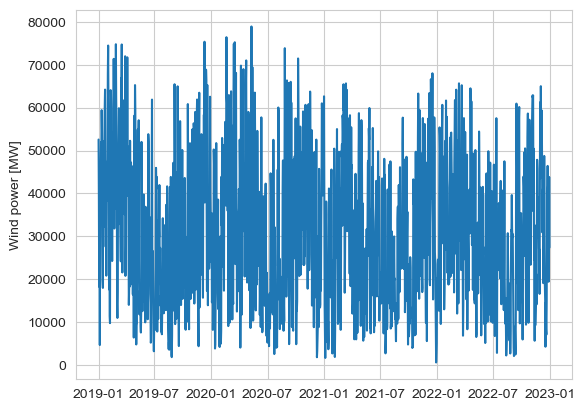

In [14]:
plt.plot(daily.Wind)
plt.ylabel('Wind power [MW]')

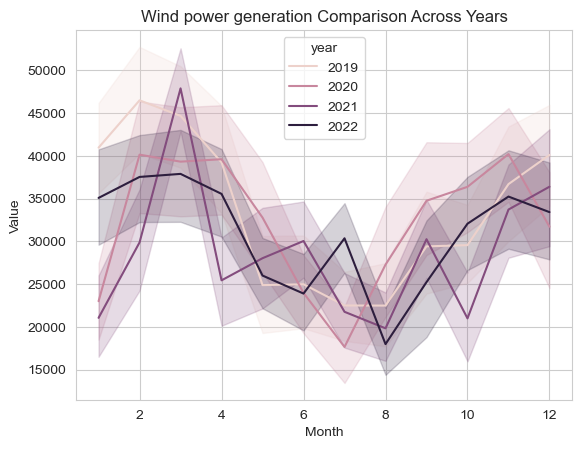

In [16]:
import seaborn as sns

sns.lineplot(x='month', y='Wind', hue='year', data=daily)
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Wind power generation Comparison Across Years')
plt.show()

Text(0, 0.5, 'Generated power')

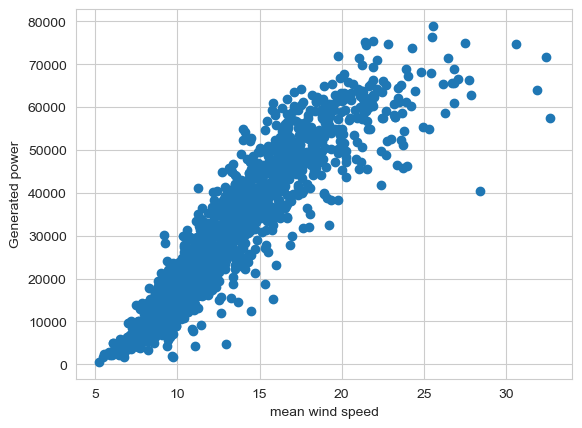

In [75]:
plt.scatter(x=daily.mean_windspeed, y=daily.Wind)
plt.xlabel('mean wind speed')
plt.ylabel('Generated power')

Text(0, 0.5, 'Generated power')

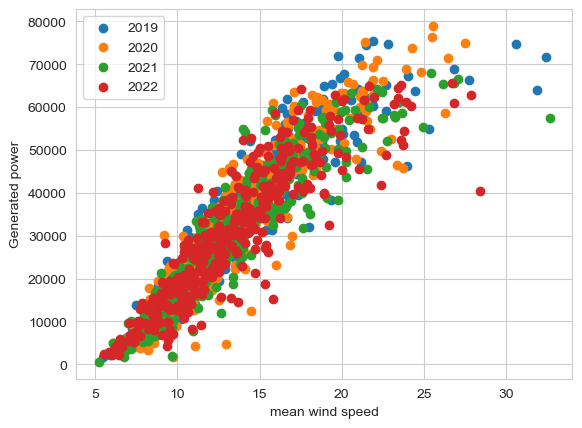

In [77]:
for year in[2020, 2021, 2022, 2023]:
    plt.scatter(daily.query(f'{year-1}<time<{year}').mean_windspeed, daily.query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
plt.legend()
plt.xlabel('mean wind speed')
plt.ylabel('Generated power')

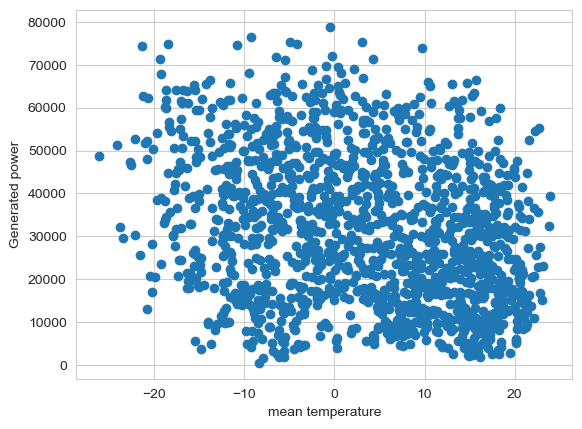

In [19]:
plt.scatter(x=daily['mean_temperature'], y=daily.Wind)
plt.xlabel('mean temperature')
plt.ylabel('Generated power')
plt.show()

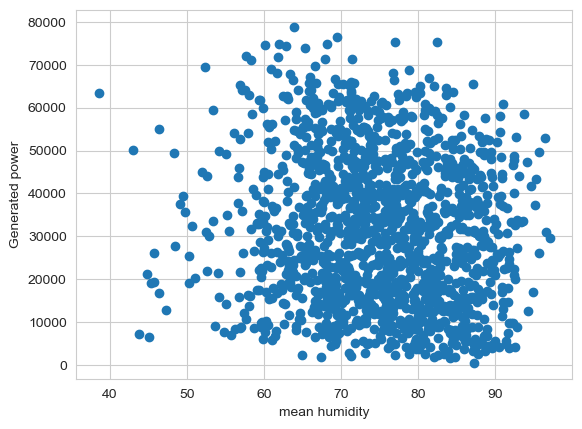

In [20]:
plt.scatter(x=daily['mean_humidity'], y=daily.Wind)
plt.xlabel('mean humidity')
plt.ylabel('Generated power')
plt.show()

Text(0, 0.5, 'Wind power')

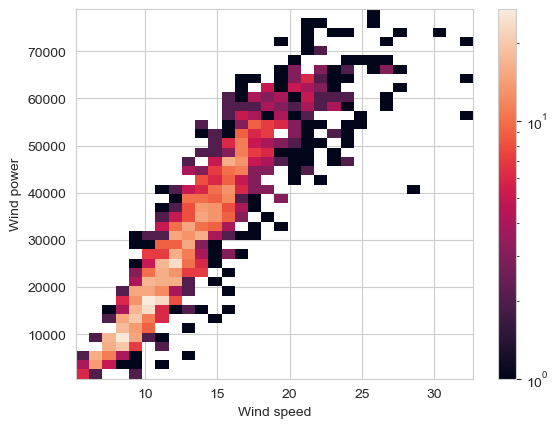

In [21]:
import matplotlib as mpl
fig, ax = plt.subplots()
h = ax.hist2d(x=daily.mean_windspeed, y=daily.Wind, bins=[30, 40], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Wind speed')
ax.set_ylabel('Wind power')

Text(0, 0.5, 'Wind power')

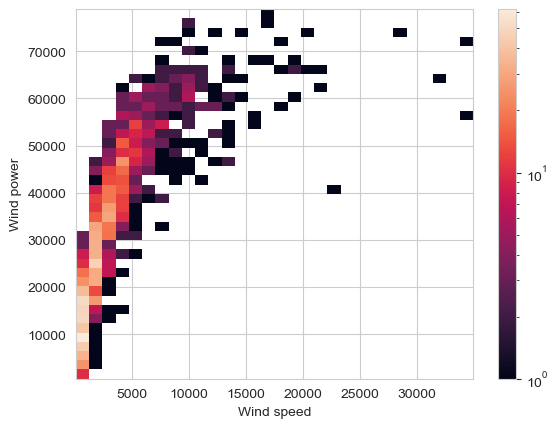

In [111]:
import matplotlib as mpl
fig, ax = plt.subplots()
h = ax.hist2d(x=daily.mean_windspeed**3, y=daily.Wind, bins=[30, 40], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Wind speed')
ax.set_ylabel('Wind power')

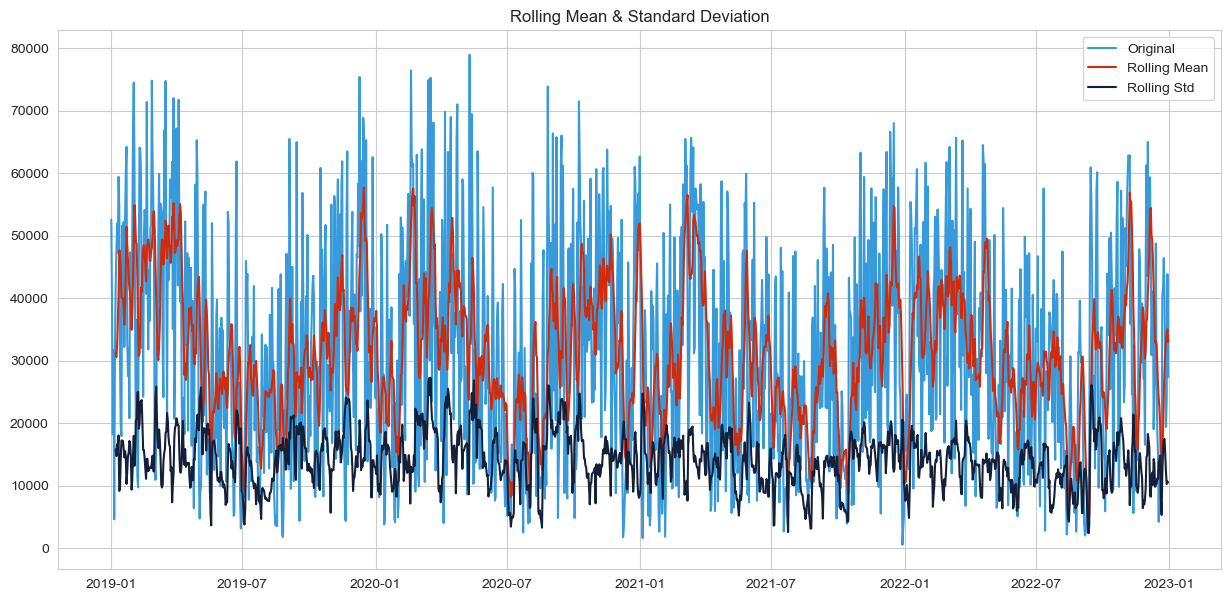

In [22]:
#Determine rolling statistics
daily["rolling_avg"] = daily["Wind"].rolling(window=7).mean() #window size 7 denotes 7 days, giving rolling mean at weekly level
daily["rolling_std"] = daily["Wind"].rolling(window=7).std()

#Plot rolling statistics
plt.figure(figsize=(15,7))
plt.plot(daily["Wind"], color='#379BDB', label='Original')
plt.plot(daily["rolling_avg"], color='#D22A0D', label='Rolling Mean')
plt.plot(daily["rolling_std"], color='#142039', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

## Augmented Dickey–Fuller Test

The Augmented Dickey-Fuller Test is used to determine if time-series data is stationary or not. Similar to a t-test, we set a significance level before the test and make conclusions on the hypothesis based on the resulting p-value.

Null Hypothesis: The data is not stationary.

Alternative Hypothesis: The data is stationary.

For the data to be stationary (ie. reject the null hypothesis), the ADF test should have:

    p-value <= significance level (0.01, 0.05, 0.10, etc.)

If the p-value is greater than the significance level then we can say that it is likely that the data is not stationary.

In [55]:
#Augmented Dickey–Fuller test:
from statsmodels.tsa.stattools import adfuller

print('Results of Dickey Fuller Test:')
dftest = adfuller(daily['Wind'], autolag='t-stat')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value


print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                   -4.958317
p-value                           0.000027
#Lags Used                       23.000000
Number of Observations Used    1437.000000
Critical Value (1%)              -3.434909
Critical Value (5%)              -2.863553
Critical Value (10%)             -2.567842
dtype: float64


In [59]:
#Augmented Dickey–Fuller test:
from statsmodels.tsa.stattools import adfuller

print('Results of Dickey Fuller Test:')
dftest = adfuller(daily.resample('M').sum()['Wind'], autolag='t-stat')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value


print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                 -4.026609
p-value                         0.001277
#Lags Used                      6.000000
Number of Observations Used    41.000000
Critical Value (1%)            -3.600983
Critical Value (5%)            -2.935135
Critical Value (10%)           -2.605963
dtype: float64


/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_12015/1220731915.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dftest = adfuller(daily.resample('M').sum()['Wind'], autolag='t-stat')


In [5]:
from pmdarima.arima.stationarity import ADFTest

adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(daily.Wind)
print(p_val, should_diff)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


0.01 False


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

In [7]:
from pmdarima.arima.utils import ndiffs

n_adf = ndiffs(daily.query('year<2021').Wind, test='adf')
print(n_adf)

0


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_12015/2236664814.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(np.linspace(1, 12, 12), daily.resample('M').sum().query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_12015/2236664814.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(np.linspace(1, 12, 12), daily.resample('M').sum().query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_12015/2236664814.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(np.linspace(1, 12, 12), daily.resample('M').sum().query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_12015/2236664814.py:2: FutureWarning: 'M'

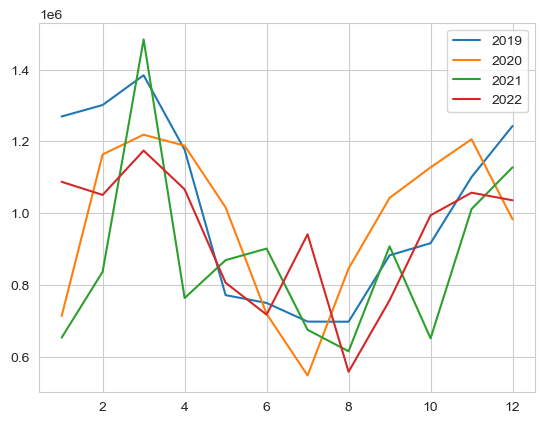

In [73]:
for year in[2020, 2021, 2022, 2023]:
    plt.plot(np.linspace(1, 12, 12), daily.resample('M').sum().query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
plt.legend()

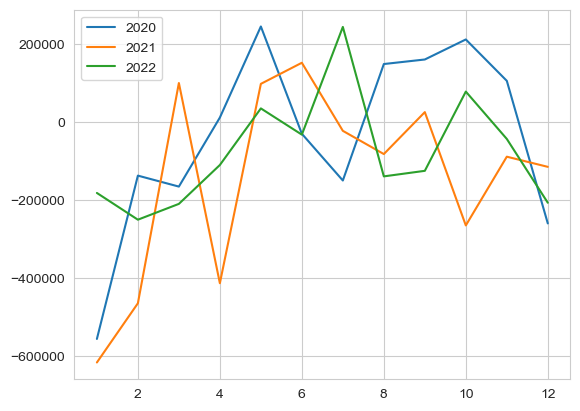

In [130]:
for year in[2021, 2022, 2023]:
    plt.plot(np.linspace(1, 12, 12), daily.resample('ME').sum().query(f'{year - 1}<time<{year}').Wind.values - daily.resample('ME').sum().query(f'2019<time<2020').Wind.values, label=f'{year-1}')
plt.legend()

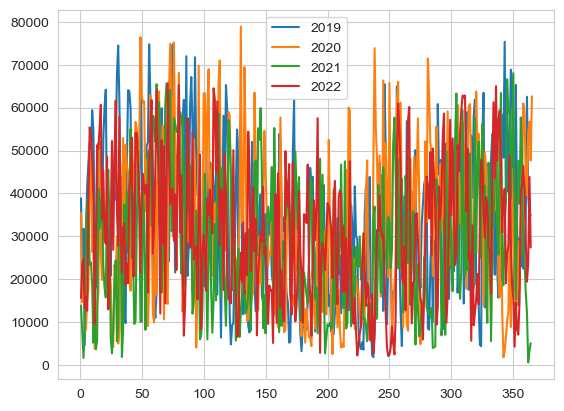

In [122]:
for year in[2020, 2021, 2022, 2023]:
    if year==2021:
        plt.plot(np.linspace(1, 365, 365), daily.query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
    else:
         plt.plot(np.linspace(1, 364, 364), daily.query(f'{year - 1}<time<{year}').Wind, label=f'{year-1}')
plt.legend()

# Simple time series models

In [14]:
from models.baselines import NaiveBaseline, RandomWalkWithDrift, NaiveSeasonalWithDrift

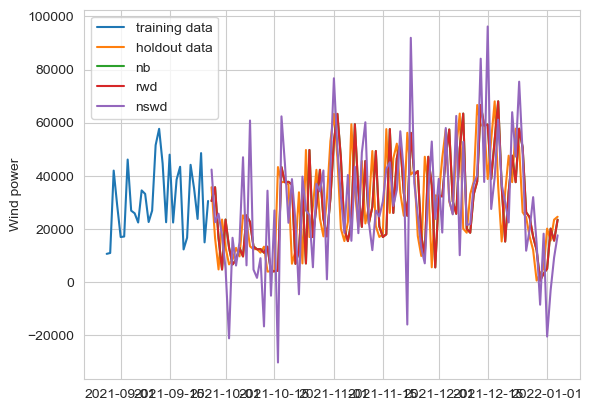

In [ ]:
nb = NaiveBaseline()
nb_forecast = []

rwd = RandomWalkWithDrift()
rwd_forecast = []

nswd = NaiveSeasonalWithDrift(season_length=365)
nswd_forecast = []

for i in range(1000, 1100):
    nb.fit(daily.Wind.iloc[:i])
    nb_forecast.append(nb.forecast(1))

    rwd.fit(daily.Wind.iloc[:i])
    rwd_forecast.append(rwd.forecast(1))

    nswd.fit(daily.Wind.iloc[:i])
    nswd_forecast.append(nswd.forecast(1))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], nb_forecast, label = 'nb')
plt.plot(daily.index[1000:1100], rwd_forecast, label = 'rwd')
plt.plot(daily.index[1000:1100], nswd_forecast, label = 'nswd')

plt.ylabel('Wind power')
plt.legend()
plt.show()

In [25]:
from statsmodels.tsa.api import ExponentialSmoothing

es_forecast = []
# Fit a "triple exponential smoothing" model with seasonal components.
for i in range(1000, 1100):
    seasonal_exp_smoothing = ExponentialSmoothing(
        daily.Wind.iloc[:i],
        trend=None,              # no trend
        seasonal="add",           # additive seasonality if amplitude is constant
        seasonal_periods=365,      # for monthly data with yearly seasonality
        initialization_method="estimated"  # more stable than "heuristic"
    ).fit()
    es_forecast.append(seasonal_exp_smoothing.forecast(steps=1))

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimizat

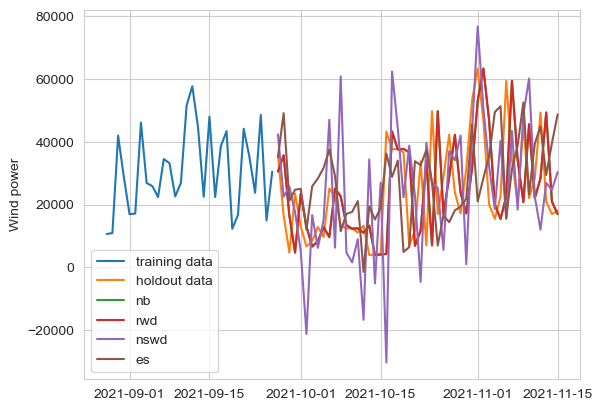

In [31]:
plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1050], daily.Wind.iloc[1000:1050], label = 'holdout data')
plt.plot(daily.index[1000:1050], nb_forecast[:50], label = 'nb')
plt.plot(daily.index[1000:1050], rwd_forecast[:50], label = 'rwd')
plt.plot(daily.index[1000:1050], nswd_forecast[:50], label = 'nswd')
plt.plot(daily.index[1000:1050], es_forecast[:50], label = 'es')

plt.ylabel('Wind power')
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

from sklearn.model_selection import TimeSeriesSplit

In [47]:
season_length = 365
forecast_length = 1
df_train = daily.iloc[:-season_length]

n_splits = 100
kfold = TimeSeriesSplit(n_splits = n_splits,
                           test_size = forecast_length)

nb_mses = np.zeros(n_splits)
rwd_mses = np.zeros(n_splits)
nswd_mses = np.zeros(n_splits)
es_mses = np.zeros(n_splits)

nb_mape = np.zeros(n_splits)
rwd_mape = np.zeros(n_splits)
nswd_mape = np.zeros(n_splits)
es_mape = np.zeros(n_splits)

for i, (train_index, test_index) in enumerate(kfold.split(df_train)):
    ts_tt = df_train.Wind.iloc[train_index]
    ts_ho = df_train.Wind.iloc[test_index]
    
    nb = NaiveBaseline()
    nb.fit(ts = ts_tt)
    nb_preds = nb.forecast(forecast_length)
    nb_mses[i] = mse(ts_ho, nb_preds)
    nb_mape[i] = mape(ts_ho, nb_preds)

    rwd = RandomWalkWithDrift()
    rwd.fit(ts_tt)
    rwd_preds = rwd.forecast(forecast_length)
    rwd_mses[i] = mse(ts_ho, rwd_preds)
    rwd_mape[i] = mape(ts_ho, rwd_preds)

    nswd = NaiveSeasonalWithDrift(season_length=365)
    nswd.fit(ts_tt)
    nswd_preds = nswd.forecast(forecast_length)
    nswd_mses[i] = mse(ts_ho, nswd_preds)
    nswd_mape[i] = mape(ts_ho, nswd_preds)

    es = ExponentialSmoothing(
            ts_tt,
            trend=None,              
            seasonal="add",           # additive seasonality if amplitude is constant
            seasonal_periods=365,      # for daily data with yearly seasonality
            initialization_method="estimated"  # more stable than "heuristic"
        ).fit()
    es_preds = es.forecast(forecast_length)
    es_mses[i] = mse(ts_ho, es_preds)
    es_mape[i] = mape(ts_ho, es_preds)

cv_mse = {'nb':nb_mses, 'rwd':rwd_mses, 'nswd':nswd_mses, 'es': es_mses}
cv_mape = {'nb':nb_mape, 'rwd':rwd_mape, 'nswd':nswd_mape, 'es': es_mape}

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimizat

In [48]:
cv_averages = {name: a.mean() for name, a in cv_mse.items()}
mape_averages = {name: a.mean() for name, a in cv_mape.items()}

print(cv_averages)
print(mape_averages)

{'nb': np.float64(349298852.97), 'rwd': np.float64(349615447.5693314), 'nswd': np.float64(593477395.03), 'es': np.float64(415102776.47350115)}
{'nb': np.float64(0.881345398154427), 'rwd': np.float64(0.8808986184532176), 'nswd': np.float64(1.291895300342764), 'es': np.float64(1.6546407003879633)}


## ARIMA Model Selection w/ Auto-ARIMA

Although our data is almost certainly not stationary (p-value = 0.991), let’s see how well a standard ARIMA model performs on the time series

Using the auto_arima() function from the pmdarima package, we can perform a parameter search for the optimal values of the model.

In [12]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

In [9]:
#Standard ARIMA Model
ARIMA_model = pm.auto_arima(daily['Wind'], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=True, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=32445.428, Time=0.82 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=34778.430, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=32635.569, Time=0.07 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,1)(0,0,0)[0]             : AIC=33942.539, Time=0.22 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,0,4)(0,0,0)[0]             : AIC=32258.937, Time=4.34 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,4)(0,0,0)[0]             : AIC=inf, Time=6.86 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=32258.381, Time=5.13 sec

Best model:  ARIMA(3,0,3)(0,0,0)[0]          
Total fit time: 44.464 seconds


## Model Diagnostics

Four plots result from the plot_diagnostics function. The Standardized residual, Histogram plus KDE estimate, Normal q-q, and the correlogram.

We can interpret the model as a good fit based on the following conditions.

### Standardized residual

There are no obvious patterns in the residuals, with values having a mean of zero and having a uniform variance.

### Histogram plus KDE estimate

The KDE curve should be very similar to the normal distribution (labeled as N(0,1) in the plot)

### Normal Q-Q

Most of the data points should lie on the straight line

### Correlogram (ACF plot)

95% of correlations for lag greater than zero should not be significant. The grey area is the confidence band, and if values fall outside of this then they are statistically significant. In our case, there are a few values outside of this area, and therefore we may need to add more predictors to make the model more accurate

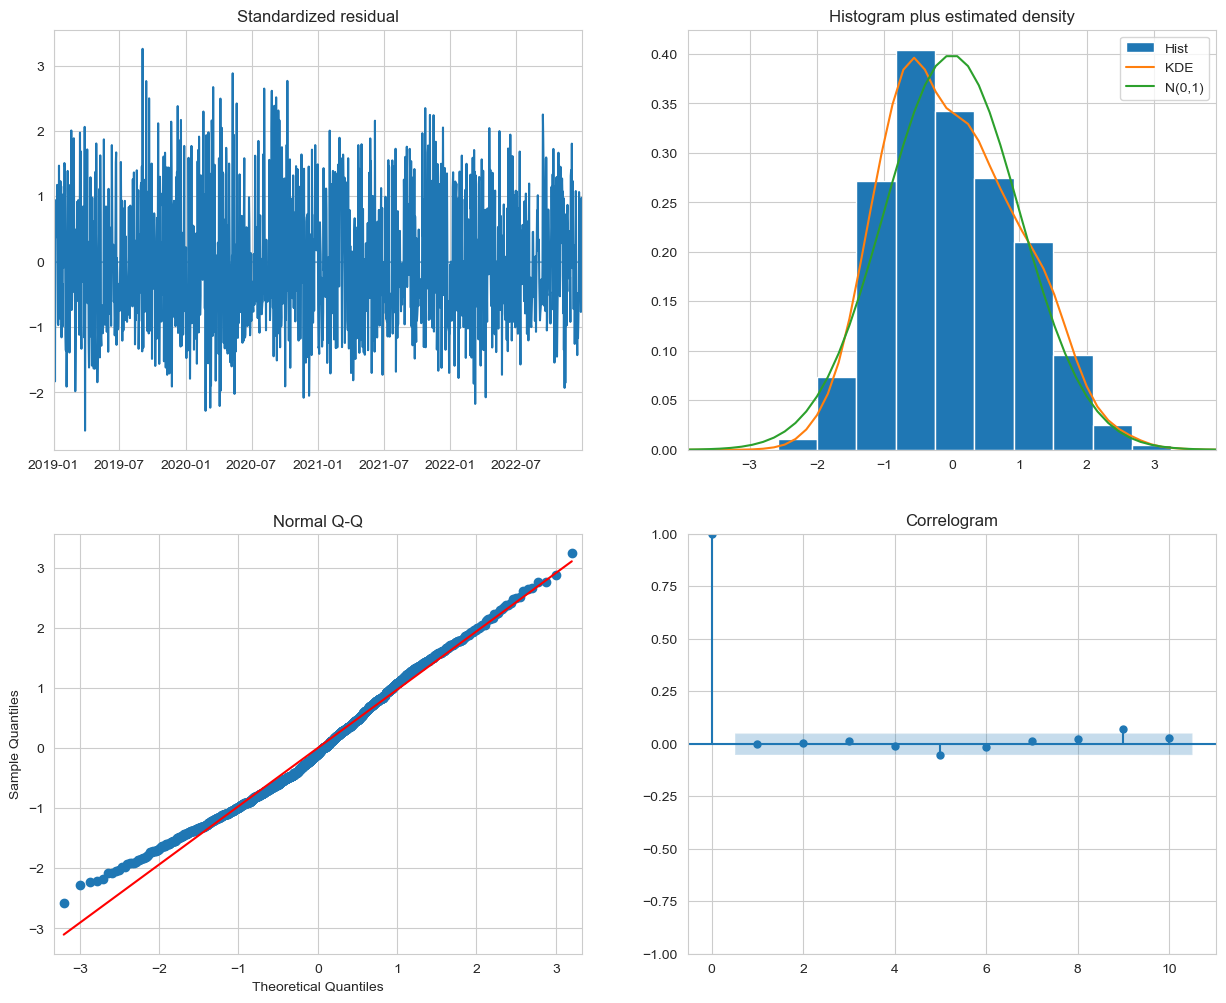

In [10]:
ARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [ ]:
def forecast(ARIMA_model, periods=1):
    # Forecast
    n_periods = periods
    fitted, confint = ARIMA_model.predict(n_periods=n_periods, return_conf_int=True)
    index_of_fc = pd.date_range(daily.index[-1] + pd.DateOffset(days=1), periods = 10)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(daily.query('year==2022 and month==12')["Wind"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)

    plt.title("ARIMA - Forecast of Wind Power Generation")
    plt.show()



/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


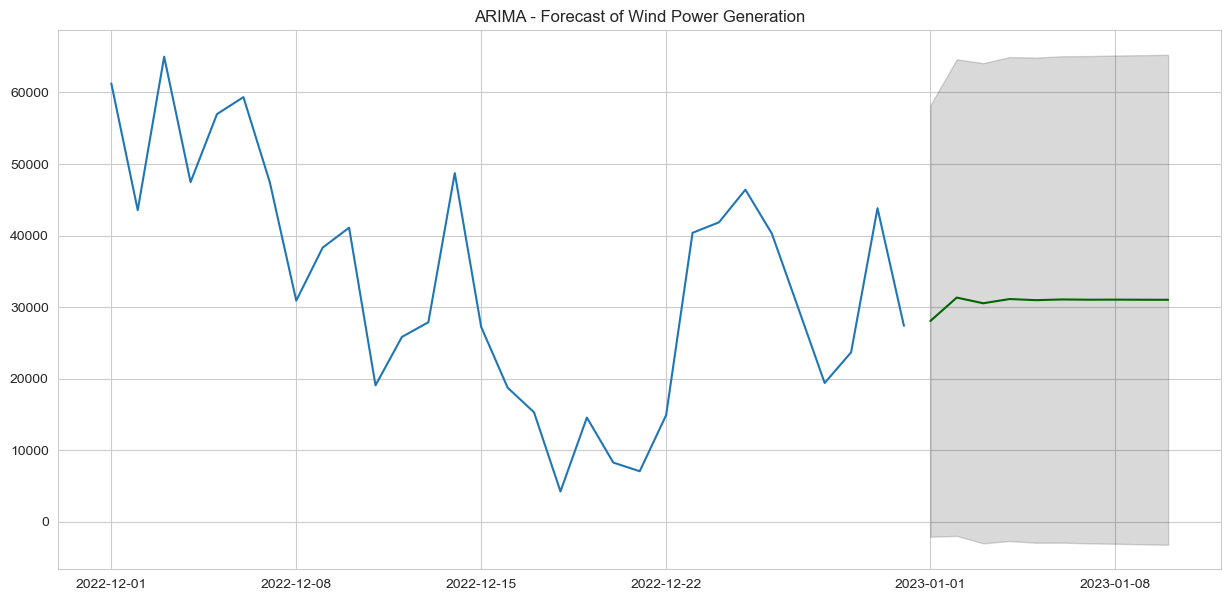

In [25]:
forecast(ARIMA_model)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

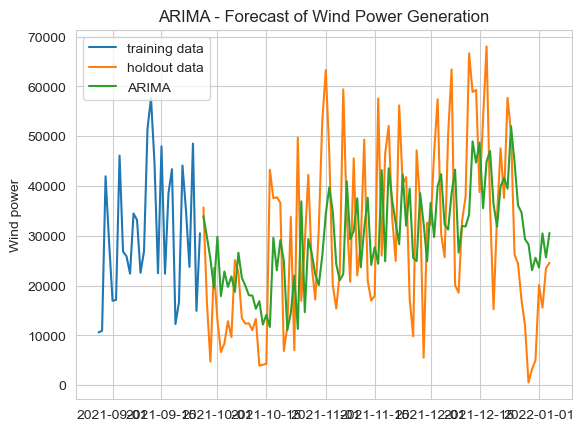

In [109]:
arima_forecast = []
arima_mses = []
arima_mape = []
for i in range(1000, 1100):
    ARIMA_model = pm.auto_arima(daily.Wind.iloc[:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model.predict(n_periods=1, return_conf_int=True)
    arima_forecast.append(fitted)
    arima_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()


In [110]:
np.mean(arima_mape)

np.float64(1.2578268398331263)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=711.946, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=676.145, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=701.025, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=674.086, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=668.965, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=668.161, Time=0.11 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=669.518, Time=0.09 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,1)(0,0,0)[0]             : AIC=668.986, Time=0.11 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=667.208, Time=0.13 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=651.781, Time=0.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.417 seconds
Performing stepwise search to minimize aic


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=650.995, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=653.107, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=653.949, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=649.012, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.532 seconds


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

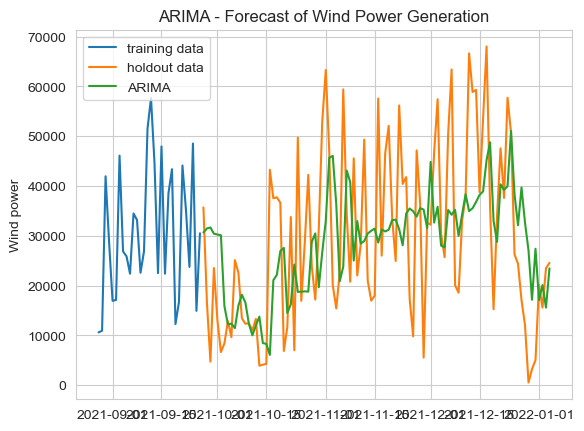

MAPE:  1.2102622497834696


In [ ]:
arima30_forecast = []
arima30_mses = []
arima30_mape = []
for i in range(1000, 1100):
    ARIMA_model = pm.auto_arima(daily.Wind.iloc[i-30:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model.predict(n_periods=1, return_conf_int=True)
    arima30_forecast.append(fitted)
    arima30_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima30_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima30_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima30_mape))


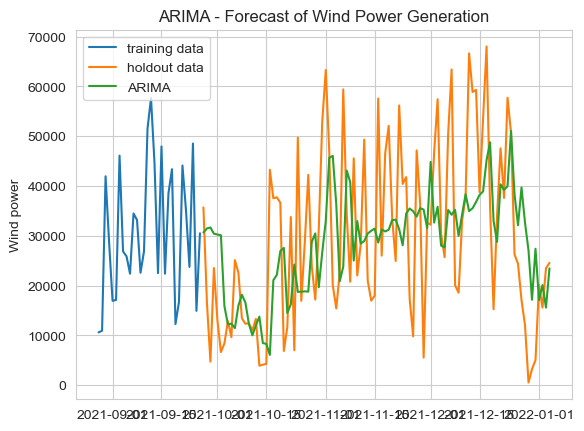

MAPE:  1.2102622497834696


In [14]:
plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima30_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima30_mape))


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

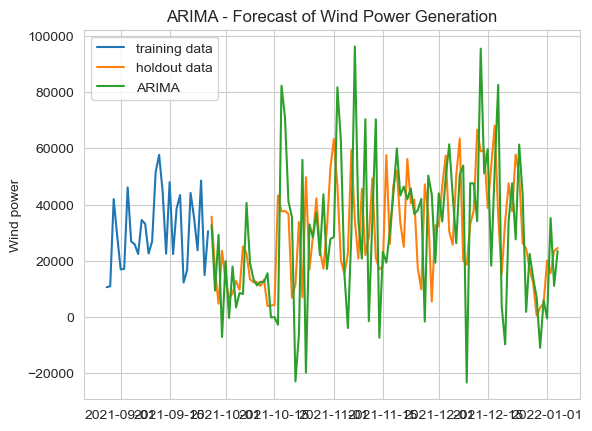

MAPE:  1.0934833433058115


In [16]:
arima7_forecast = []
arima7_mses = []
arima7_mape = []
for i in range(1000, 1100):
    ARIMA_model7 = pm.auto_arima(daily.Wind.iloc[i-14:i], 
                            start_p=1, 
                            start_q=1,
                            test='adf', # use adftest to find optimal 'd'
                            max_p=7, max_q=7, # maximum p and q
                            m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                            d=None,# let model determine 'd'
                            seasonal=False, # No Seasonality for standard ARIMA
                            trace=False, #logs 
                            error_action='warn', #shows errors ('ignore' silences these)
                            suppress_warnings=True,
                            stepwise=True)
    fitted, confint = ARIMA_model7.predict(n_periods=1, return_conf_int=True)
    arima7_forecast.append(fitted)
    arima7_mses.append(mse(np.array(daily.iloc[i][['Wind']]), fitted))
    arima7_mape.append(mape(np.array(daily.iloc[i][['Wind']]), fitted))

plt.plot(daily.index[970:1000], daily.Wind.iloc[970:1000], label = 'training data')
plt.plot(daily.index[1000:1100], daily.Wind.iloc[1000:1100], label = 'holdout data')
plt.plot(daily.index[1000:1100], arima7_forecast, label = 'ARIMA')

plt.title("ARIMA - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(arima7_mape))


## SARIMA Model

Now let’s try the same strategy as we did above, except let’s use a SARIMA model so that we can account for seasonality.

In [26]:
# Seasonal - fit stepwise auto-ARIMA
SARIMA_model = pm.auto_arima(daily["Wind"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=365, #365 is the frequncy of the cycle
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=None, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

: 

Taking a look at the model diagnostics, we can see some significant differences when compared with the standard ARIMA model.

### Standardized residual

The Standardized residual is much more consistent across the graph, meaning that the data is closer to being stationary.

### Histogram plus KDE estimate

The KDE curve is similar to the normal distribution (not much changed here).

### Normal Q-Q

The data points are clustered much closer to the line than in the ARIMA diagnostic plot.

### Correlogram (ACF plot)

The grey area is the confidence band, and if values fall outside of this then they are statistically significant. We want all values inside this area. Adding the seasonality component did this! All the points now fall within the 95% confidence interval.

In [ ]:
SARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

NameError: name 'SARIMA_model' is not defined

In [ ]:
forecast(SARIMA_model)

## SARIMAx Model Selection

Now let’s add in an exogenous variable. I am going to add the average wind speed as an exogenous variable.

## Using StatsForecast

In [17]:
from statsforecast import StatsForecast

In [81]:
sf_daily = pd.DataFrame()
sf_daily['y'] = daily['Wind']
sf_daily['ds'] = daily.index
sf_daily['unique_id'] = 'A'

sf_train = sf_daily.query('ds<2022')
sf_test = sf_daily.query('ds>2022')

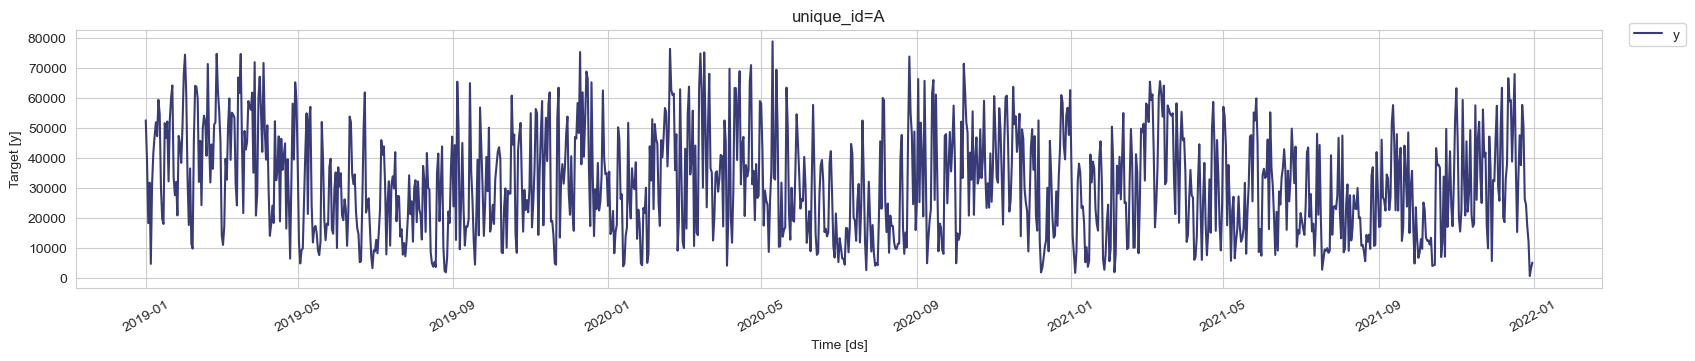

In [19]:
StatsForecast.plot(sf_train)

In [20]:
from statsforecast.models import (
    AutoARIMA,
    HoltWinters,
    CrostonClassic as Croston, 
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive
)

In [21]:
models = [
    AutoARIMA(),
    HoltWinters(),
    Croston(),
    SeasonalNaive(season_length=365),
    HistoricAverage(),
    DOT(season_length=365)
]

In [22]:
# Instantiate StatsForecast class as sf
sf = StatsForecast( 
    models=models,
    freq='D', 
    fallback_model = SeasonalNaive(season_length=365),
    n_jobs=-1,
)
sf.fit(sf_train)

StatsForecast(models=[AutoARIMA,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta])

In [23]:
forecasts_df = sf.forecast(df=sf_train, h=10, level=[90])
forecasts_df.head()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,A,2022-01-01,21145.881154,-4159.139697,46450.902006,37071.0,-2626.491408,76768.491408,37071.0,-2626.491408,76768.491408,37071.0,-2626.491408,76768.491408,31439.566606,2389.347487,60489.785725,19857.058324,-4686.893555,50814.796875
1,A,2022-01-02,28665.899692,789.180644,56542.618739,13829.0,-25868.491408,53526.491408,13829.0,-25868.491408,53526.491408,13829.0,-25868.491408,53526.491408,31439.566606,2389.347487,60489.785725,19857.058324,-8869.570312,43516.105469
2,A,2022-01-03,28779.778149,741.065134,56818.491164,7501.0,-32196.491408,47198.491408,7501.0,-32196.491408,47198.491408,7501.0,-32196.491408,47198.491408,31439.566606,2389.347487,60489.785725,19857.058324,-13664.522461,45772.683594
3,A,2022-01-04,30180.850980,1880.499804,58481.202157,1604.0,-38093.491408,41301.491408,1604.0,-38093.491408,41301.491408,1604.0,-38093.491408,41301.491408,31439.566606,2389.347487,60489.785725,19857.058324,-8938.337891,43476.863281
4,A,2022-01-05,29646.645705,1286.563661,58006.727748,8779.0,-30918.491408,48476.491408,8779.0,-30918.491408,48476.491408,8779.0,-30918.491408,48476.491408,31439.566606,2389.347487,60489.785725,19857.058324,-4266.861328,50555.839844


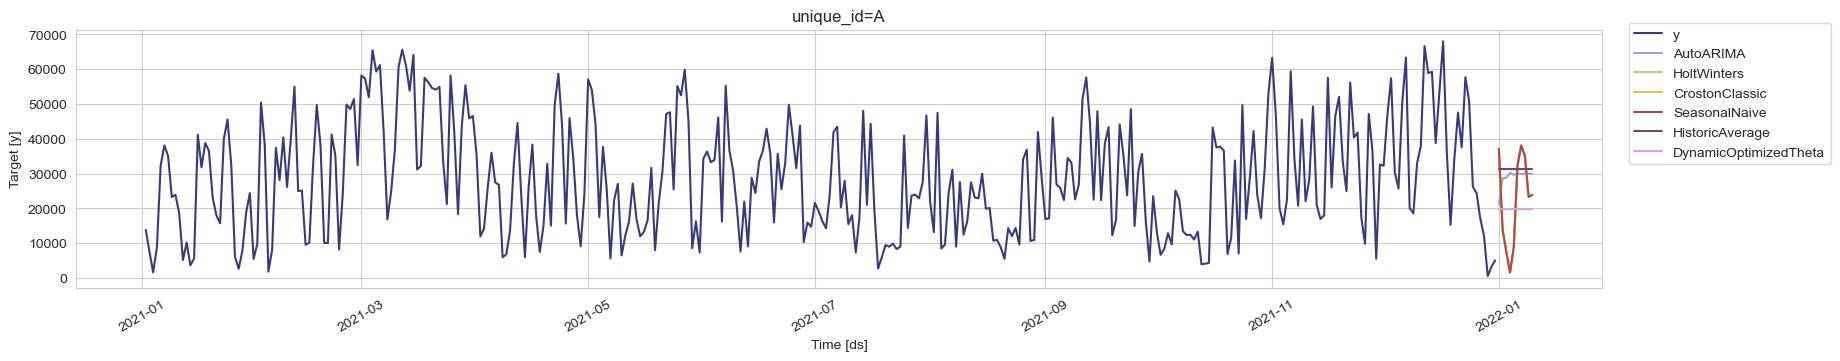

In [24]:
sf.plot(sf_train.query('ds>2021'),forecasts_df)


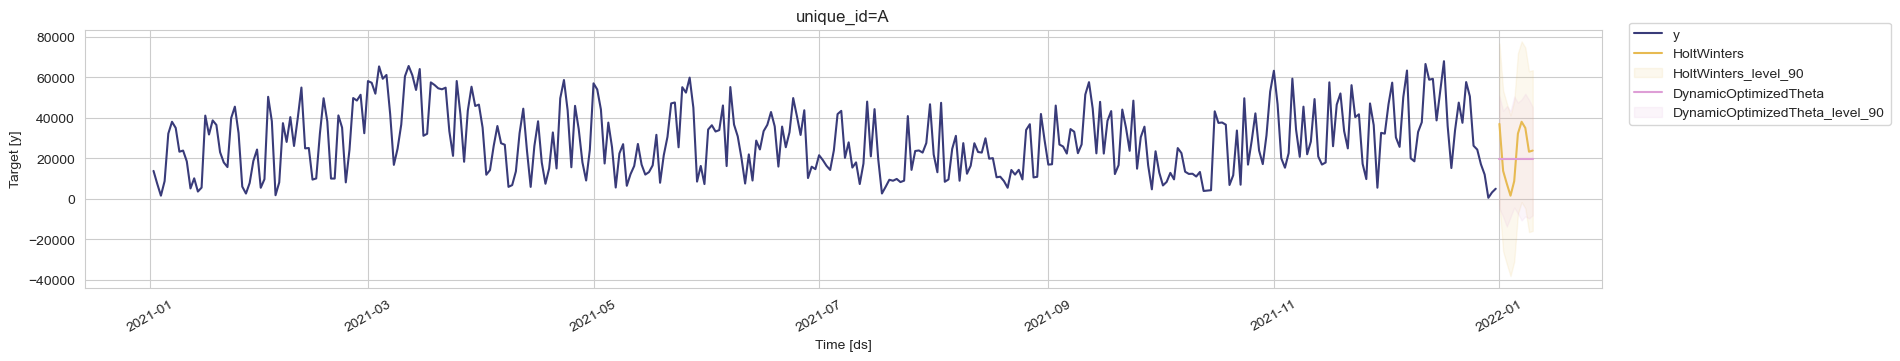

In [25]:
sf.plot(sf_train.query('ds>2021'), forecasts_df, models=["HoltWinters","DynamicOptimizedTheta"], level=[90])

### Cross-validation

In [26]:
cv_df = sf.cross_validation(
    df=sf_daily,
    h=1,
    step_size=1,
    n_windows=10
)

In [27]:
from utilsforecast.losses import mse

In [28]:
def evaluate_cv(df, metric):
    models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
    evals = metric(df, models=models)
    evals['best_model'] = evals[models].idxmin(axis=1)
    return evals

In [29]:
evaluation_df = evaluate_cv(cv_df, mse)
evaluation_df.head()

,unique_id,AutoARIMA,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,best_model
0,A,9.653424e+07,445207281.0,1.524609e+08,445207281.0,1.147742e+08,2.003117e+08,AutoARIMA


In [30]:
evaluation_df['best_model'].value_counts().to_frame().reset_index()

,best_model,count
0,AutoARIMA,1


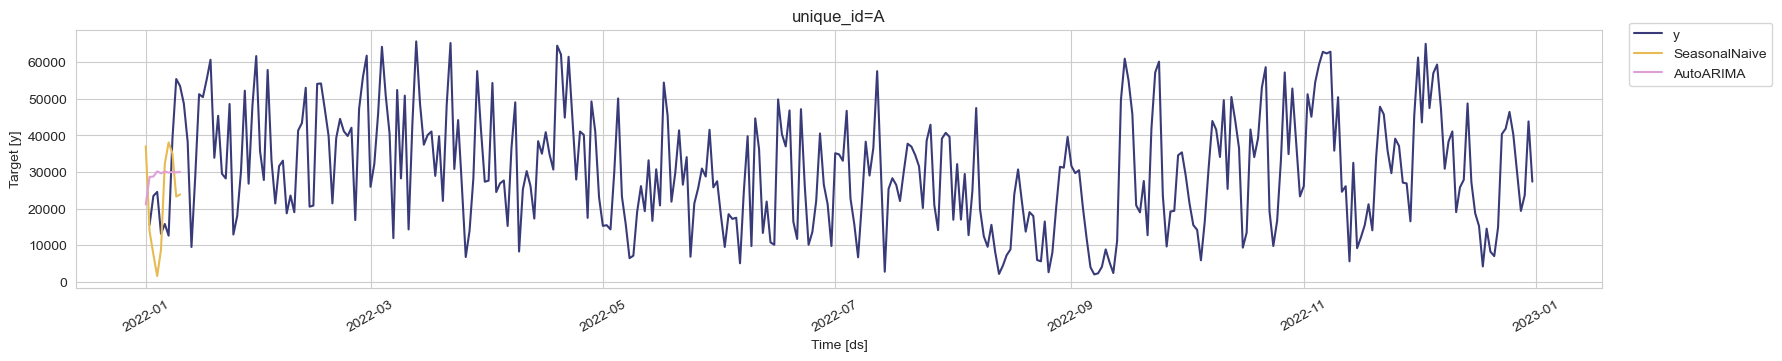

In [31]:
seasonal_ids = evaluation_df.query('best_model == "AutoARIMA"')['unique_id']
sf.plot(sf_daily.query('ds>2022'),forecasts_df, unique_ids=seasonal_ids, models=["SeasonalNaive","AutoARIMA"])

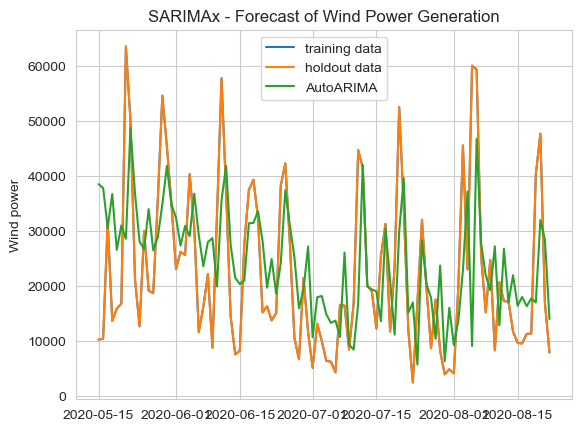

MAPE:  0.6980972683862774


In [87]:
horizon = 1
level = [90]

mses = []
mapes = []
predictions_autoArima = []
for i in range(500, 600):
    tt = sf_daily.iloc[i-30:i]
    sf = StatsForecast(models=models, freq='D', fallback_model = SeasonalNaive(season_length=365), n_jobs=-1,)
    forecasts_df = sf.forecast(df=tt, h=horizon, level=level)
    predictions_autoArima.append(forecasts_df.AutoARIMA.values)
    mses.append(mse(np.array(sf_daily.iloc[i][['y']]), forecasts_df.AutoARIMA.values))
    mapes.append(mape(np.array(sf_daily.iloc[i][['y']]), forecasts_df.AutoARIMA.values))
plt.plot(sf_daily.index[500:600], sf_daily.y.iloc[500:600], label = 'training data')
plt.plot(sf_daily.index[500:600], sf_daily.y.iloc[500:600], label = 'holdout data')
plt.plot(sf_daily.index[500:600], predictions_autoArima, label = 'AutoARIMA')

plt.title("SARIMAx - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(mapes))    

# SARIMAx

In [84]:
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape


In [34]:
sf_daily = pd.DataFrame()
sf_daily['ds'] = daily.index
sf_daily['unique_id'] = 'A'
sf_daily['y'] = daily['Wind'].values
sf_daily['windspeed'] = daily['mean_windspeed'].values

sf_train = sf_daily.query('ds<2021')
sf_test = sf_daily.query('ds>2021')

sf_train.head()

,ds,unique_id,y,windspeed
0,2019-01-01,A,52554.0,18.808882
1,2019-01-02,A,38859.0,14.186294
2,2019-01-03,A,18209.0,9.101206
3,2019-01-04,A,31732.0,14.528947
4,2019-01-05,A,4615.0,6.905592


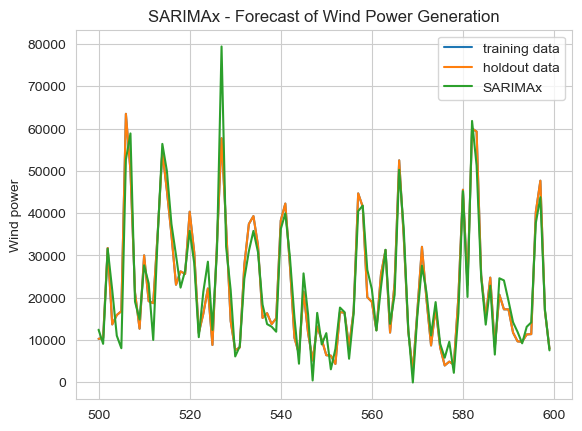

MAPE:  0.20354014256710845


In [77]:
horizon = 1
level = [90]

forecast30 = []
mses30 = []
mape30 = []
models = [AutoARIMA(season_length=365)]

for i in range(500, 600):
    sfm30 = StatsForecast(models=models, freq='D', n_jobs=-1,)
    fcst = sfm30.forecast(df=sf_train.iloc[i-30:i], h=horizon, X_df=sf_train.drop(columns='y').iloc[i:i+1], level=level)
    forecast30.append(fcst.AutoARIMA.values)
    mses30.append(mse(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))
    mape30.append(mape(np.array(sf_train.iloc[i][['y']]), fcst.AutoARIMA.values))

plt.plot(sf_train.index[500:600], sf_train.y.iloc[500:600], label = 'training data')
plt.plot(sf_train.index[500:600], sf_train.y.iloc[500:600], label = 'holdout data')
plt.plot(sf_train.index[500:600], forecast30, label = 'SARIMAx')

plt.title("SARIMAx - Forecast of Wind Power Generation")
plt.ylabel('Wind power')
plt.legend()
plt.show()
print('MAPE: ', np.mean(mape30))    



In [35]:
# Create a list with the model and its instantiation parameters 
models = [AutoARIMA(season_length=365)]

sfm = StatsForecast(
    models=models, 
    freq='D', 
    n_jobs=-1,
)
sfm.fit(sf_train.iloc[:-30])

StatsForecast(models=[AutoARIMA])

In [50]:
horizon = 1
level = [90]

fcst = sfm.forecast(df=sf_train.iloc[:30], h=horizon, X_df=sf_train.drop(columns='y').iloc[30:31], level=level)
fcst.head()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90
0,A,2019-01-31,56432.595871,46065.485091,66799.706651


# Autocorrelation

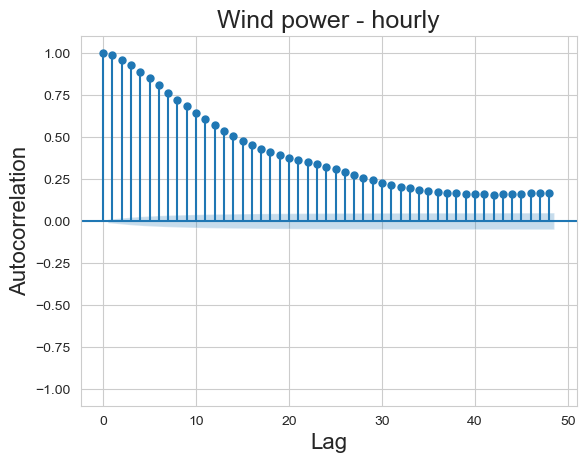

In [92]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(df.Wind,
                            lags = 48)

plt.title('Wind power - hourly', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

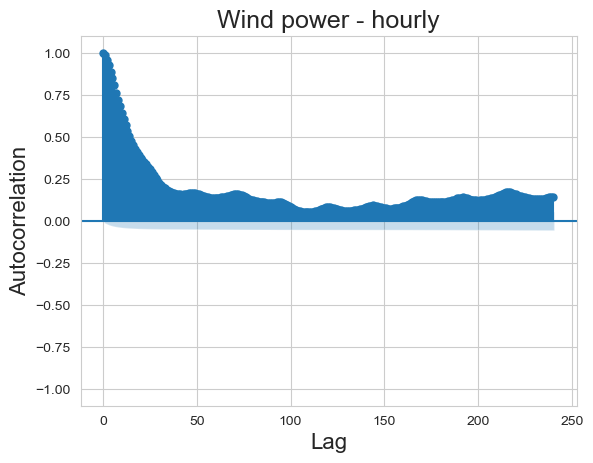

In [ ]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(df.Wind,
                            lags = 240)

plt.title('Wind power - hourly', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

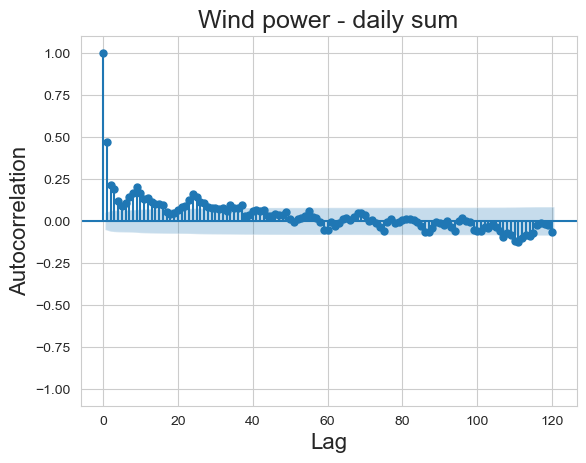

In [49]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(daily.Wind,
                            lags = 120)

plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

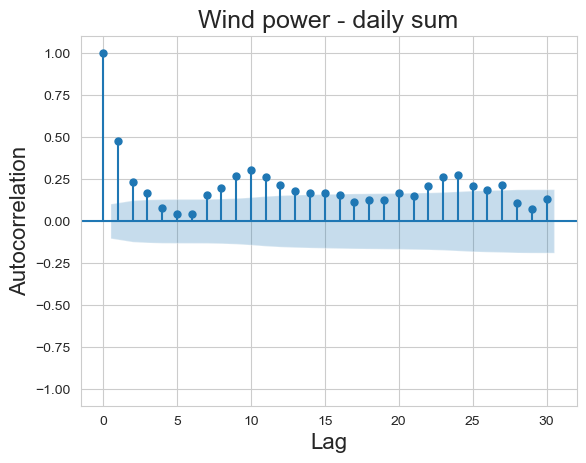

In [51]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(daily.query('year==2019').Wind,
                            lags = 30)

plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

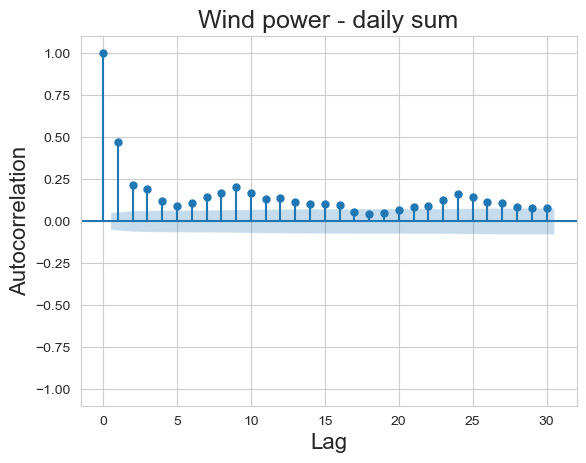

In [94]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(daily.Wind,
                            lags = 30)

plt.title('Wind power - daily sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

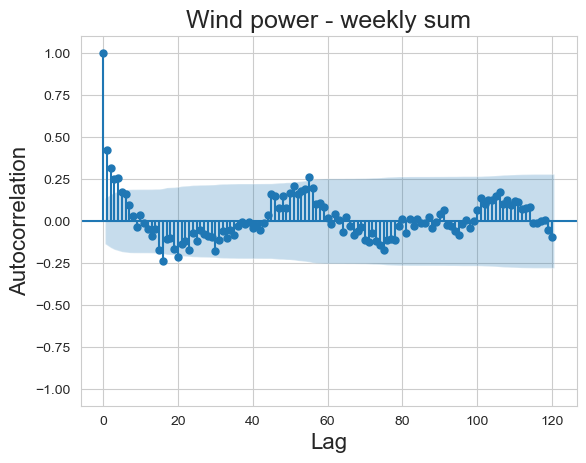

In [17]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(weekly_sum.Wind,
                            lags = 120)

plt.title('Wind power - weekly sum', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

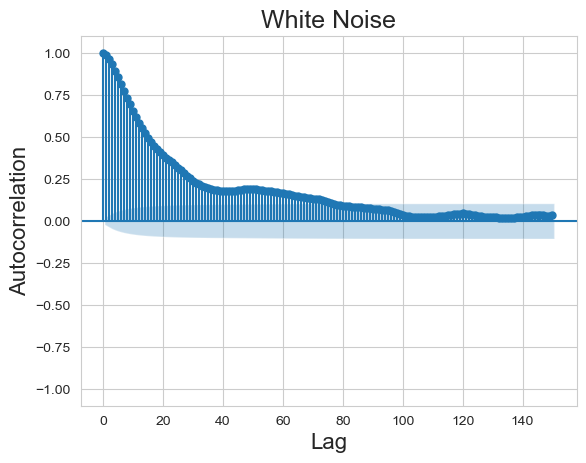

In [12]:
## first put in the time series
## then set how many lags you want to consider
## the default is lags=30
sm.graphics.tsa.plot_acf(df.query('Year==2019').Wind,
                            lags = 150)

plt.title('White Noise', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

plt.ylim(-1.1,1.1)

plt.show()

This means that the time series of wind power production is not stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

adfuller(df[['Wind']], maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-17.60471843059314),
 np.float64(3.905814454507369e-30),
 52,
 35011,
 {'1%': np.float64(-3.43053679213716),
  '5%': np.float64(-2.8616225575095284),
  '10%': np.float64(-2.566813942767471)},
 np.float64(438611.3964255577))

In [21]:

adfuller(df[['Wind']], maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

(np.float64(-17.710406772008234),
 0.0,
 52,
 35011,
 {'1%': np.float64(-3.959028601927475),
  '5%': np.float64(-3.410615407961136),
  '10%': np.float64(-3.1271238542779667)},
 np.float64(438609.68229164125))

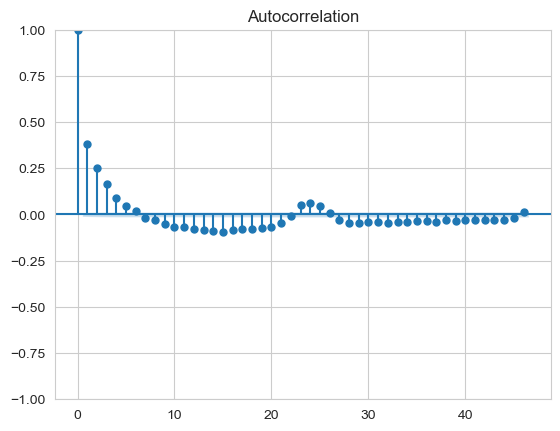

In [13]:
sm.graphics.tsa.plot_acf(df.Wind.diff()[1:])
plt.show()

In [22]:
sm.tsa.stattools.pacf(df.Wind,  method = 'ols')[:6]

array([ 1.        ,  0.98541443, -0.39078754, -0.14521747, -0.06024575,
       -0.01440601])

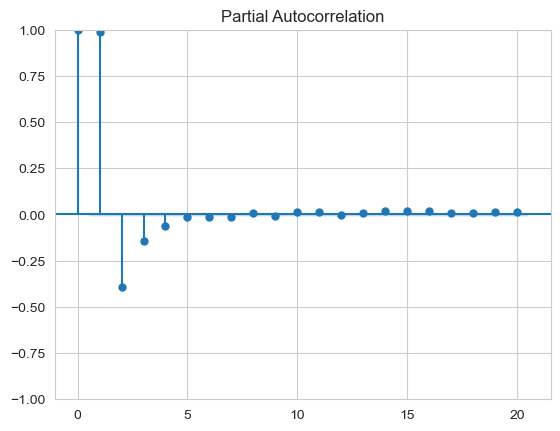

In [24]:
sm.graphics.tsa.plot_pacf(df.Wind, lags=20, method='ols')
plt.show()

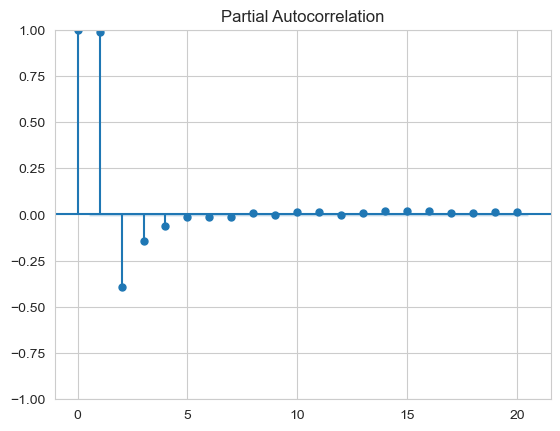

In [26]:
sm.graphics.tsa.plot_pacf(df.Wind, lags=20,)
plt.show()

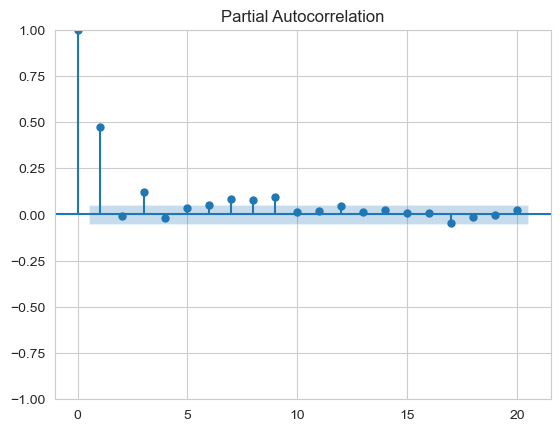

In [25]:
sm.graphics.tsa.plot_pacf(daily_sum.Wind, lags=20, method='ols')
plt.show()

In [27]:
from pmdarima import auto_arima

In [28]:
auto_arima(daily_sum.Wind, trace=True)

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=32231.452, Time=1.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=32703.731, Time=0.06 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=32605.276, Time=0.16 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,3)(0,0,0)[0]             : AIC=32227.704, Time=2.00 sec


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,5)(0,0,0)[0]             : AIC=32222.762, Time=5.73 sec

Best model:  ARIMA(2,1,4)(0,0,0)[0]          
Total fit time: 53.366 seconds


ARIMA(order=(2, 1, 4), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [31]:
import statsmodels.tsa.api as sm
# This is how we fit the model
model = sm.ARIMA(daily_sum.Wind, order = (2, 1, 4)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   Wind   No. Observations:                 1461
Model:                 ARIMA(2, 1, 4)   Log Likelihood              -16103.165
Date:                Thu, 12 Jun 2025   AIC                          32220.330
Time:                        15:28:36   BIC                          32257.333
Sample:                    01-01-2019   HQIC                         32234.134
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0855      0.108     10.025      0.000       0.873       1.298
ar.L2         -0.7909      0.090     -8.747      0.000      -0.968      -0.614
ma.L1         -1.6154      0.110    -14.702      0.000      -1.831      -1.400
ma.L2          1.0436      0.142      7.354      0.000       0.765       1.322
ma.L3         -0.0739      0.055     -1.338      0.181      -0.182       0.034
ma.L4         -0.3016      0.040     -7.630      0.000      -0.379      -0.224
sigma2      2.298e+08   9.95e-11   2.31e+18      0.000     2.3e+08     2.3e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                35.34
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                             0.31
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.46e+34. Standard errors may be unstable.
"""

In [32]:
model.forecast(10)

2023-01-01    28640.477054
2023-01-02    32807.081574
2023-01-03    32129.237538
2023-01-04    30858.100122
2023-01-05    30014.315205
2023-01-06    30103.657697
2023-01-07    30867.967798
2023-01-08    31626.999601
2023-01-09    31846.489196
2023-01-10    31484.457879
Freq: D, Name: predicted_mean, dtype: float64

In [36]:
training_set = daily_sum.iloc[:1000]


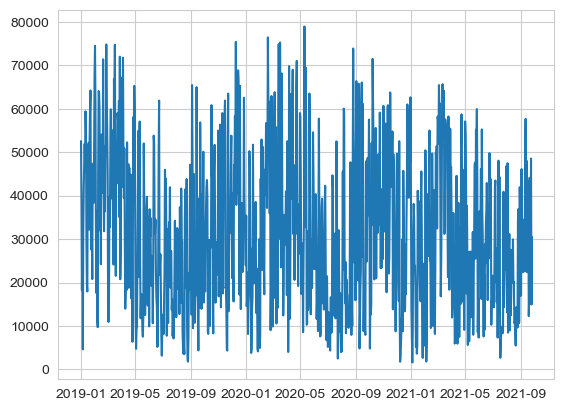

In [38]:
plt.plot(training_set.index, training_set.Wind)

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

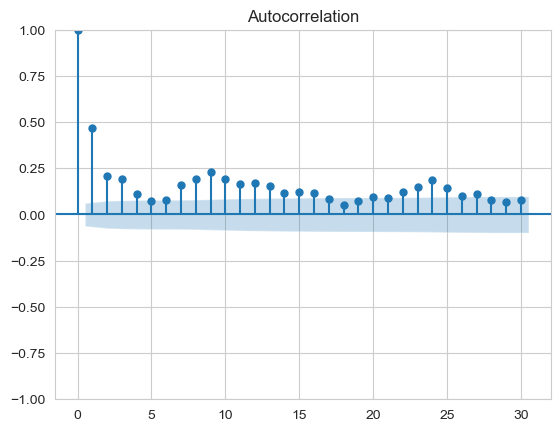

In [43]:
plot_acf(training_set.Wind)
plt.show()

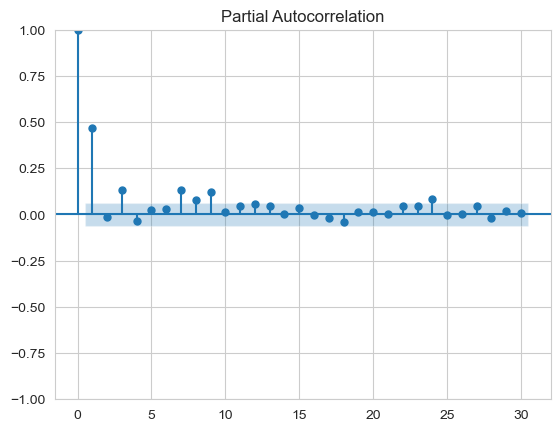

In [45]:
plot_pacf(training_set.Wind)
plt.show()

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

In [46]:
import numpy as np

def X_y_for_lags(ts, num_lags):
    '''
    Inputs
        ts: A numpy array of size (n,) representing a time series
        num_lags: The number of lags to include in the resulting design matrix

    Outputs
        X: A numpy array of size (n - num_lags, num_lags). 
            The first column is lag 1, second column is lag 2, etc 
        y: The time series starting at entry num_lags
    '''
    ts = ts.astype(float)
    n = len(ts)
    X = np.zeros(shape=(n - num_lags, num_lags))
    for i in range(num_lags):
        X[:, i] = ts[num_lags - i - 1 : n - i - 1]
    y = ts[num_lags:]
    return X, y

# Test cases
assert np.array_equal(
    X_y_for_lags(np.array([1, 2, 3, 4, 5, 6]), 2)[0], 
    np.array([
        [2., 1.], 
        [3., 2.], 
        [4., 3.], 
        [5., 4.]])
)

assert np.array_equal(
    X_y_for_lags(np.array([1, 2, 3, 4, 5, 6]), 2)[1], 
    np.array([3., 4., 5., 6.])
)


In [51]:
model1 = LinearRegression()
model2 = LinearRegression()

model0_preds = []
model1_preds = []
model2_preds = []
model3_preds = []
model4_preds = []


design_matrix, targets = X_y_for_lags(training_set.Wind.values, 9)

for i in range(-10, 0):

    X_tt, y_tt = design_matrix[:i], targets[:i]

    # The holdout data should have a single row!
    X_ho, y_ho = design_matrix[[i]], targets[i]

    # X_tt_1 is used for model 1 and should only use lags 1 and 2.
    # Remember that lag 1 is at index 0!
    X_tt_1 = X_tt[:,[0,1]]

    # X_tt_2 is used for model 2 an should only use lags 1, 3 and 7, 8, 9
    X_tt_2 = X_tt[:,[0, 2, 6, 7, 8]]

    X_ho_1 = X_ho[:,[0,1]]
    X_ho_2 = X_ho[:,[0, 2, 6, 7, 8]]

    X_tt_4 = X_tt_2
    X_ho_4 = X_ho_2

    # Fit the models
    model1.fit(X_tt_1, y_tt)
    model2.fit(X_tt_2, y_tt)
    model3 = auto_arima(y_tt)

    kr = KernelRidge()
    param_grid = {'gamma': np.logspace(-3, 2, 6)}
    grid_search = GridSearchCV(kr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_tt_1, y_tt)
    model4 = grid_search.best_estimator_


    # Model 0 is the naive forecast
    model0_preds.append(y_tt[-1])
    model1_preds.append(model1.predict(X_ho_1)[0])
    model2_preds.append(model2.predict(X_ho_2)[0])
    model3_preds.append(model3.predict(1))
    model4_preds.append(model4.predict(X_ho_1)[0])



/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

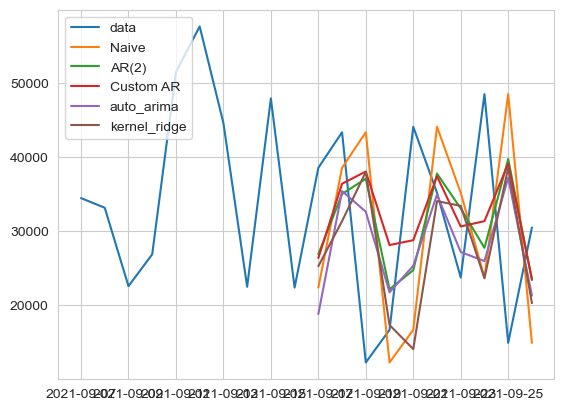

In [57]:
plt.plot(training_set.index[-20:], training_set.iloc[-20:]['Wind'], label = 'data')
plt.plot(training_set.index[-10:], model0_preds, label = 'Naive')
plt.plot(training_set.index[-10:], model1_preds, label = 'AR(2)')
plt.plot(training_set.index[-10:], model2_preds, label = 'Custom AR')
plt.plot(training_set.index[-10:], model3_preds, label = 'auto_arima')
plt.plot(training_set.index[-10:], model4_preds, label = 'kernel_ridge')
plt.legend()
plt.show()

In [52]:
from sklearn.metrics import mean_squared_error as mse

In [60]:
mse0 = mse(training_set[-10:]['Wind'],model0_preds)
mse1 = mse(training_set[-10:]['Wind'],model1_preds)
mse2 = mse(training_set[-10:]['Wind'],model2_preds)
mse3 = mse(training_set[-10:]['Wind'],model3_preds)
mse4 = mse(training_set[-10:]['Wind'],model4_preds)

unordered_dict = {'Model 0':mse0, 'Model 1':mse1, 'Model 2':mse2, 'Model 3':mse3, 'Model 4':mse4}
ordered_dict = dict(sorted(unordered_dict.items(), key=lambda item: item[1], reverse=True))
ordered_dict

{'Model 0': 422108626.2,
 'Model 4': 326393040.935016,
 'Model 1': 242011420.2495169,
 'Model 3': 235075445.5364936,
 'Model 2': 221006268.9868663}

In [62]:
model2 = LinearRegression()
model2_preds = []

design_matrix, targets = X_y_for_lags(daily_sum.iloc[-1000:].Wind.values, 9)

for i in range(-10, 0):

    X_tt, y_tt = design_matrix[:i], targets[:i]

    # The holdout data should have a single row!
    X_ho, y_ho = design_matrix[[i]], targets[i]

    # X_tt_2 is used for model 2 an should only use lags 1, 3 and 7, 8, 9
    X_tt_2 = X_tt[:,[0, 2, 6, 7, 8]]
    X_ho_2 = X_ho[:,[0, 2, 6, 7, 8]]

    # Fit the models
    model2.fit(X_tt_2, y_tt)

    # Model 0 is the naive forecast
    model2_preds.append(model2.predict(X_ho_2)[0])

mse(y[-10:], model2_preds)

NameError: name 'y' is not defined

In [63]:
aa_preds = []
for days in range(-10, 0):
    aa = auto_arima(training_set[:days].Wind)
    aa_preds.append(aa.predict(1))
    


/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andreafodor/anaconda3/envs/erdos_summer_2025/lib/

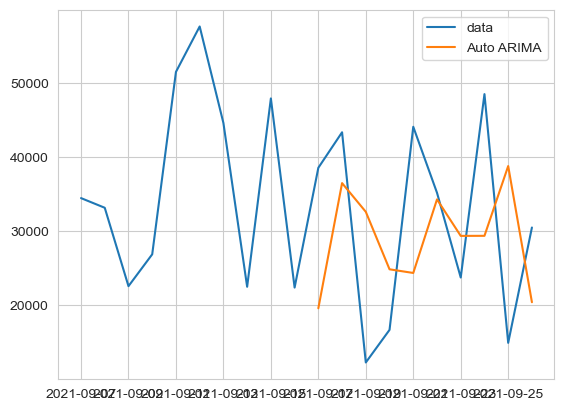

In [64]:
plt.plot(training_set.index[-20:], training_set.iloc[-20:]['Wind'], label = 'data')
plt.plot(training_set.index[-10:], aa_preds, label = 'Auto ARIMA')
plt.legend()
plt.show()

# Linear Regression

In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[["mean_windspeed", "mean_temperature"]], daily.query('year<2022').Wind
)

LinearRegression()

In [90]:
mlr_model.intercept_

np.float64(-18160.410096656222)

In [91]:
mlr_model.coef_

array([3691.9640316 ,  -44.65687582])

In [96]:
preds = mlr_model.predict(daily.query('year==2022')[['mean_windspeed', 'mean_temperature']])
print(mape(daily.query('year==2022').Wind.values, preds))


0.22024189884609432


In [97]:
from sklearn.metrics import r2_score
print(r2_score(daily.query('year==2022').Wind.values, preds))

0.7852878630635252
